# El Martillo OCR Analysis

This notebook performs OCR on a page from the "El Martillo" newspaper using the Claude API, structures the data, and provides basic analysis.

In [8]:
import os
import base64
import json
import pandas as pd
import matplotlib.pyplot as plt
import anthropic
from dotenv import load_dotenv

# Load environment variables
load_dotenv()

api_key = os.getenv("ANTHROPIC_API_KEY")
if not api_key:
    print("WARNING: ANTHROPIC_API_KEY not found in environment variables. Please set it in a .env file or environment.")


In [9]:
def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')

image_path = "data/el_martillo/page_01.png"
base64_image = encode_image(image_path)


In [37]:
client = anthropic.Anthropic(api_key=api_key)

prompt = """
You are a historian and data archivist. Your task is to transcribe and structure the content of this newspaper page from 'El Martillo'.

Please extract the following information for each distinct article, advertisement, or section found on the page:
1. Date (if visible on the page, otherwise use 'Unknown')
2. Issue Number (if visible, otherwise 'Unknown')
3. Headline (Title of the article or ad)
4. Section (e.g., Politics, Local News, Ads, Editorial)
5. Type (Article, Advertisement, Notice, Poetry, Other)
6. Text Excerpt (The first few sentences or a summary of the content)

Notes:
- The sectioning is based on the paper structure, not on the content of the article. Additionally, you should include ALL the text of the section not only the first few sentences.
- As we're using only one page, the issue number is the same.
- Return the output strictly as a JSON list of objects. Do not include any markdown formatting or explanation outside the JSON.
Example format:
[
  {
    "date": "...",
    "issue_number": "...",
    "headline": "...",
    "section": "...",
    "type": "...",
    "text_excerpt": "..."
  }
]
"""

try:
    message = client.messages.create(
        model="claude-sonnet-4-5",
        max_tokens=4096,
        messages=[
            {
                "role": "user",
                "content": [
                    {
                        "type": "image",
                        "source": {
                            "type": "base64",
                            "media_type": "image/png",
                            "data": base64_image
                        }
                    },
                    {
                        "type": "text",
                        "text": prompt
                    }
                ]
            }
        ]
    )
    
    response_text = message.content[0].text
    # Clean up if there are markdown code blocks
    if "```json" in response_text:
        response_text = response_text.split("```json")[1].split("```")[0].strip()
    elif "```" in response_text:
        response_text = response_text.split("```")[1].split("```")[0].strip()
        
    data = json.loads(response_text)
    print(f"Successfully extracted {len(data)} items.")
    
except Exception as e:
    print(f"Error during API call or parsing: {e}")
    data = []


Successfully extracted 2 items.


In [45]:
# Create DataFrame
df = pd.DataFrame(data)

# Display first few rows
df.head()

,date,issue_number,headline,section,type,text_excerpt
0,AGOSTO 5 DE 1916,1609,El periodismo departamental,Editorial,Article,"CHICLAYO, AGOSTO 5 DE 1916.\n\nEl periodismo d..."
1,AGOSTO 5 DE 1916,1609,ROMULO MENCHOLA,Ads,Advertisement,ROMULO MENCHOLA\n\nVENDEDOR Y COBRADOR\n\nDe l...


In [44]:
# Save to CSV
csv_path = "el_martillo_dataset.csv"
df.to_csv(csv_path, index=False)
print(f"Dataset saved to {csv_path}")

Dataset saved to el_martillo_dataset.csv


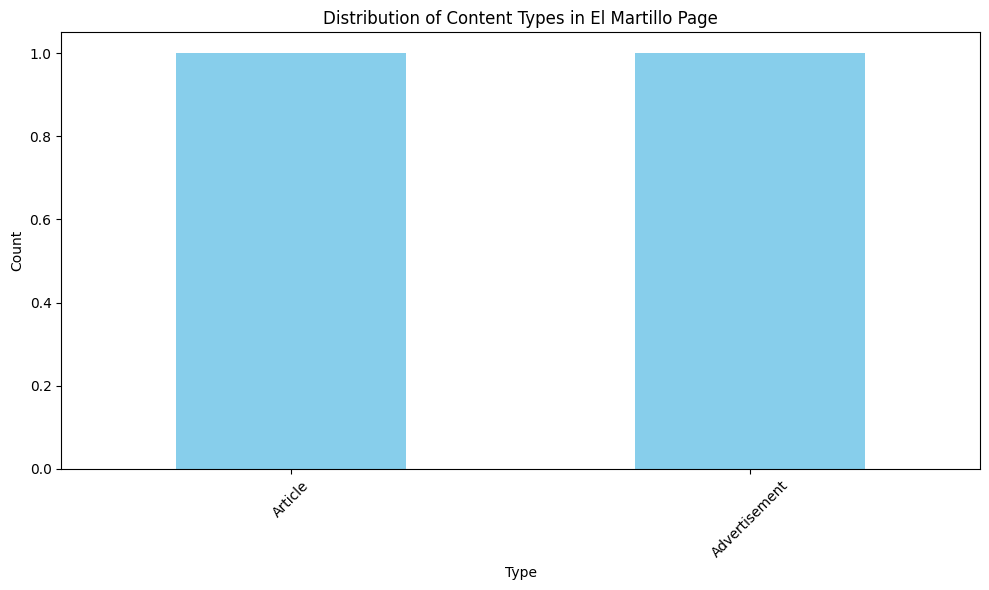

In [46]:
# Visualization: Distribution of Content Types
if not df.empty:
    plt.figure(figsize=(10, 6))
    type_counts = df['type'].value_counts()
    type_counts.plot(kind='bar', color='skyblue')
    plt.title('Distribution of Content Types in El Martillo Page')
    plt.xlabel('Type')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No data to visualize.")

In [48]:
if df.empty:
    print("No data extracted.")
else:
    print("Insights:")
    print(f"Total items extracted: {len(df)}")

    # --- Most common section (handles multiple modes & empty/NaNs) ---
    if "section" in df.columns:
        sections = df["section"].dropna()
        if sections.empty:
            common_section = "N/A"
        else:
            modes = sections.mode()
            if len(modes) == 1:
                common_section = modes.iloc[0]
            else:
                # join all modes if there's a tie
                common_section = ", ".join(modes.astype(str))
        print(f"Most common section(s): {common_section}")
    else:
        print("Most common section(s): N/A (no 'section' column)")

    # --- Date info (very simple, just takes the first one if exists) ---
    if "date" in df.columns and not df["date"].empty:
        date_found = df["date"].iloc[0]
    else:
        date_found = "Unknown"
    print(f"Date found: {date_found}")


Insights:
Total items extracted: 2
Most common section(s): Ads, Editorial
Date found: AGOSTO 5 DE 1916
